In [2]:
import os

os.chdir("/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code")
print("Current Working Directory: ", os.getcwd())

Current Working Directory:  /ceph/behrens/peter_doohan/goalNav_mFC/experiment/code


In [3]:
from importlib import reload
from matplotlib import pyplot as plt
from matplotlib.gridspec import GridSpec

plt.rcParams.update(
    {
        "font.size": 10,
        "axes.titlesize": 10,
        "axes.labelsize": 10,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "figure.titlesize": 10,
        "pdf.fonttype": 42,
    }
)

In [9]:
from pathlib import Path

FIG_SAVE_PATH = Path("../results/figures/4.structured_reps")

# Example cells

In [4]:
from GridMaze.analysis.core import get_clusters as gc
from GridMaze.analysis.cluster_tuning import spatial

In [29]:
pd_plotting_kwargs = {
    "minimum_occupancy": 0.5,
    "navigation_only": True,
    "moving_only": True,
    "exclude_time_at_goal": False,
    "fixed_vmin": False,
    "colormap": "heat",
    "silhouette_node_size": 500,
    "silhouette_edge_size": 10,
    "star_base_length": 0.05,
    "max_point_length": 0.035,
}

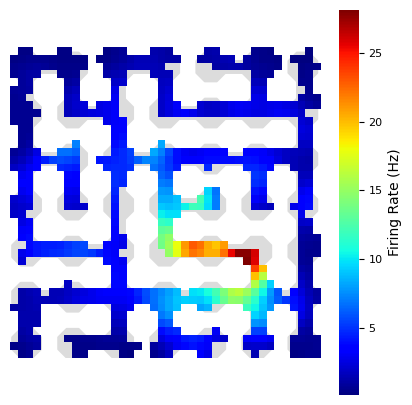

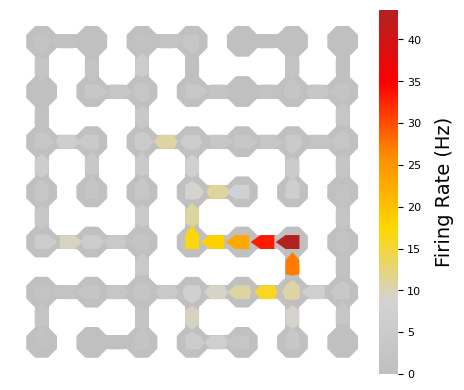

In [31]:
reload(gc)
reload(spatial)
Cluster = gc.get_cluster("m6.2022-06-30.maze_cluster49")
f, ax = plt.subplots(1, 1, figsize=(5, 5))
Cluster.plot_tuning(feature="spatial", ax=ax)
f, ax = plt.subplots(1, 1, figsize=(5, 5))
Cluster.plot_tuning(feature="place_direction", feature_kwargs=pd_plotting_kwargs, ax=ax)

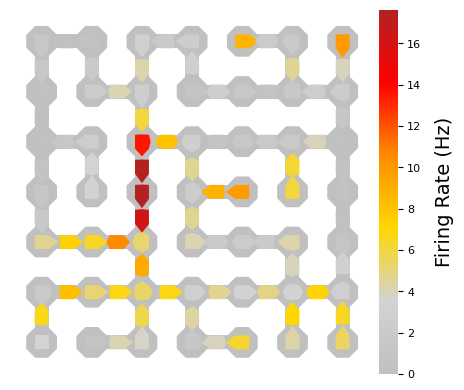

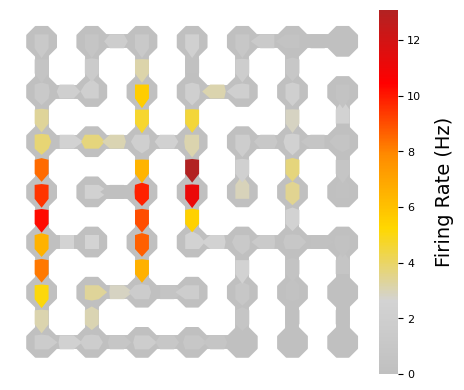

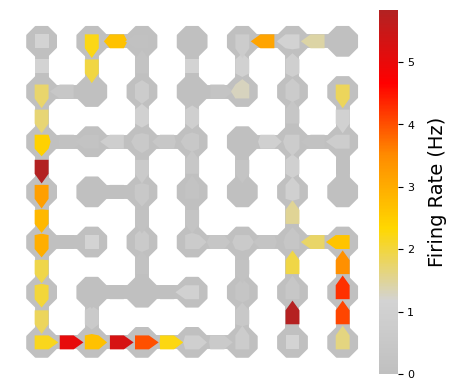

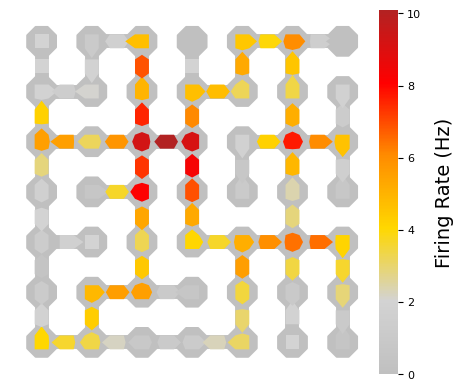

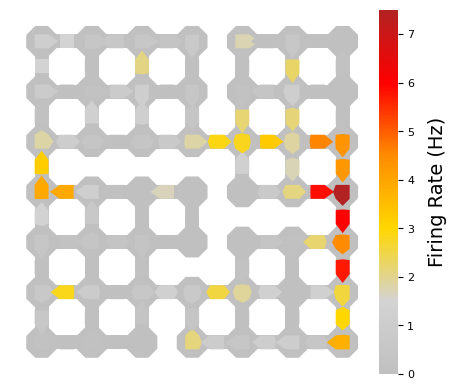

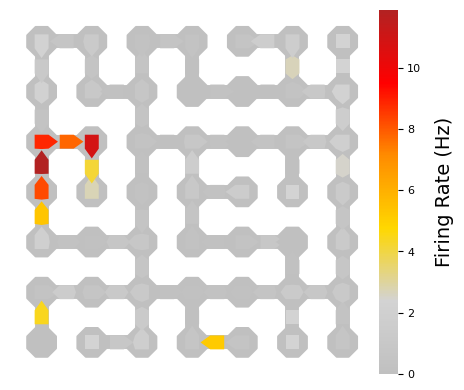

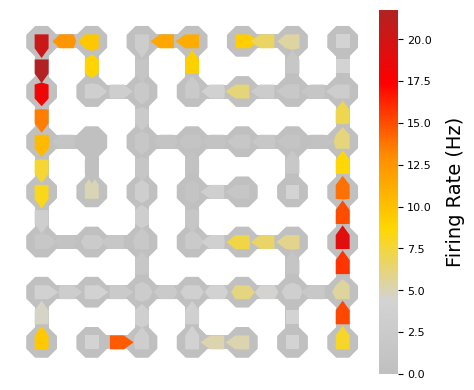

In [32]:
example_clusters = [
    "m3.2022-06-29.maze_cluster85",
    "m3.2022-07-11.maze_cluster52",
    "m3.2022-07-14.maze_cluster6",
    "m3.2022-07-14.maze_cluster85",
    "m3.2022-07-24.maze_cluster65",
    "m6.2022-07-04.maze_cluster52",
    "m6.2022-07-04.maze_cluster94",
]
for c in example_clusters:
    Cluster = gc.get_cluster(c)
    f, ax = plt.subplots(1, 1, figsize=(5, 5))
    Cluster.plot_tuning(feature="place_direction", feature_kwargs=pd_plotting_kwargs, ax=ax)

### Dimensionality reduction to visualise population tuning

In [11]:
from GridMaze.maze import representations as mr
from GridMaze.analysis.place_direction import dimensionality_reduction as pdr

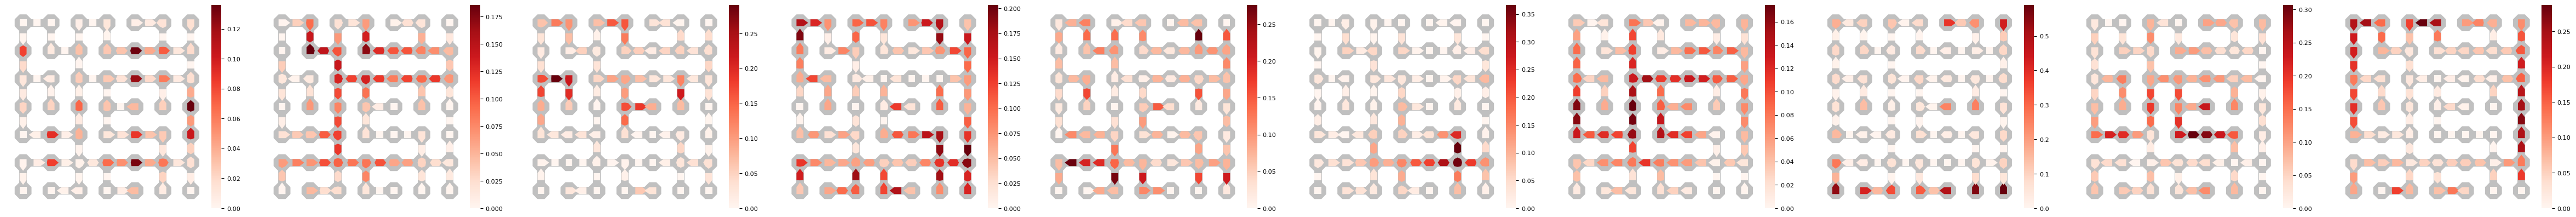

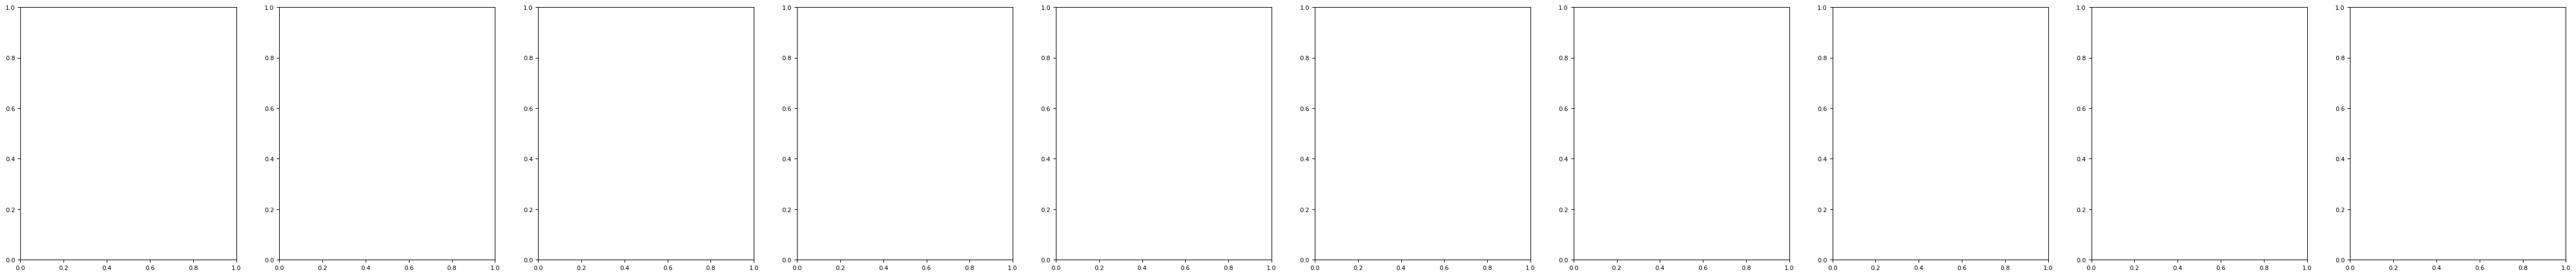

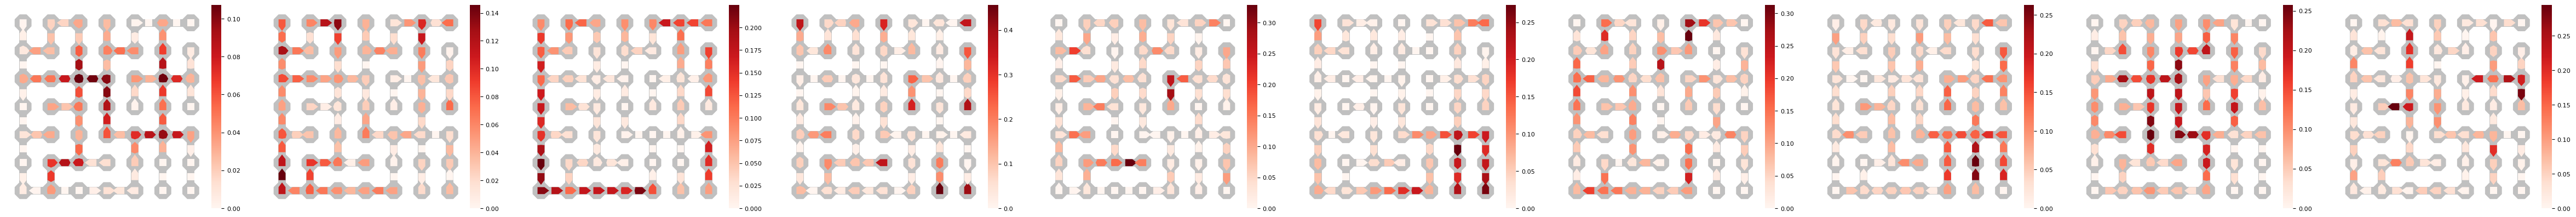

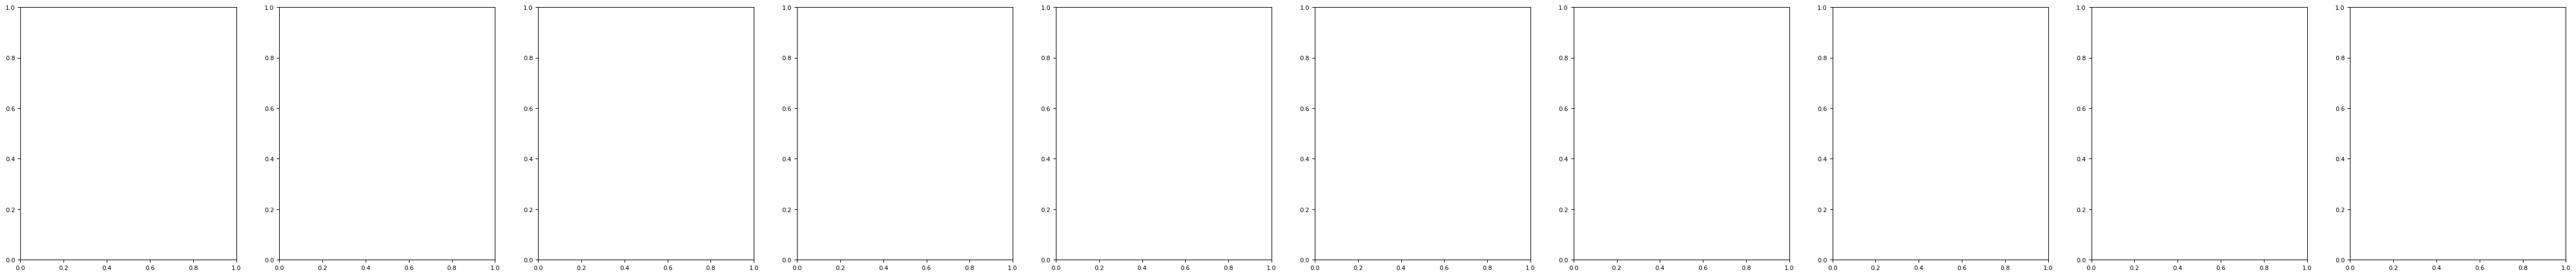

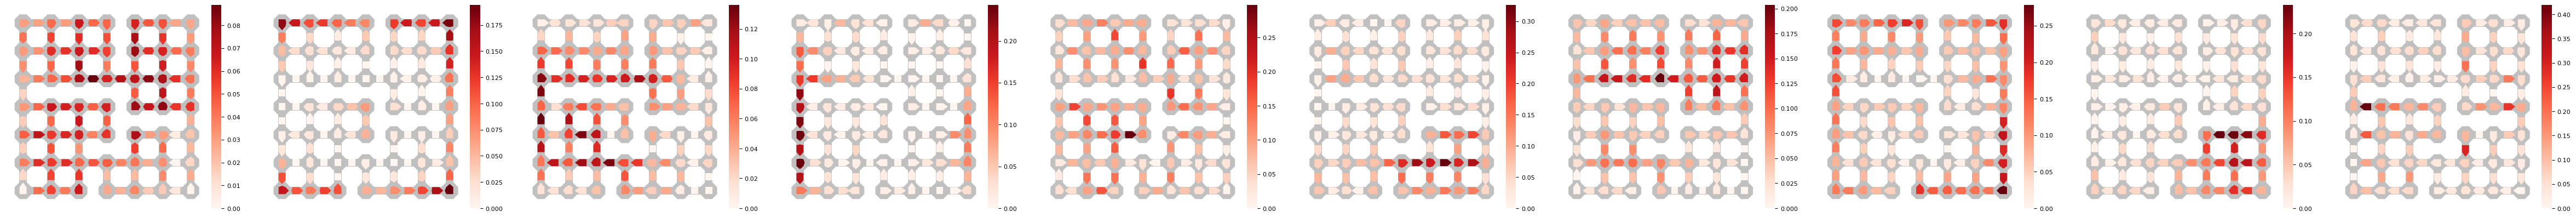

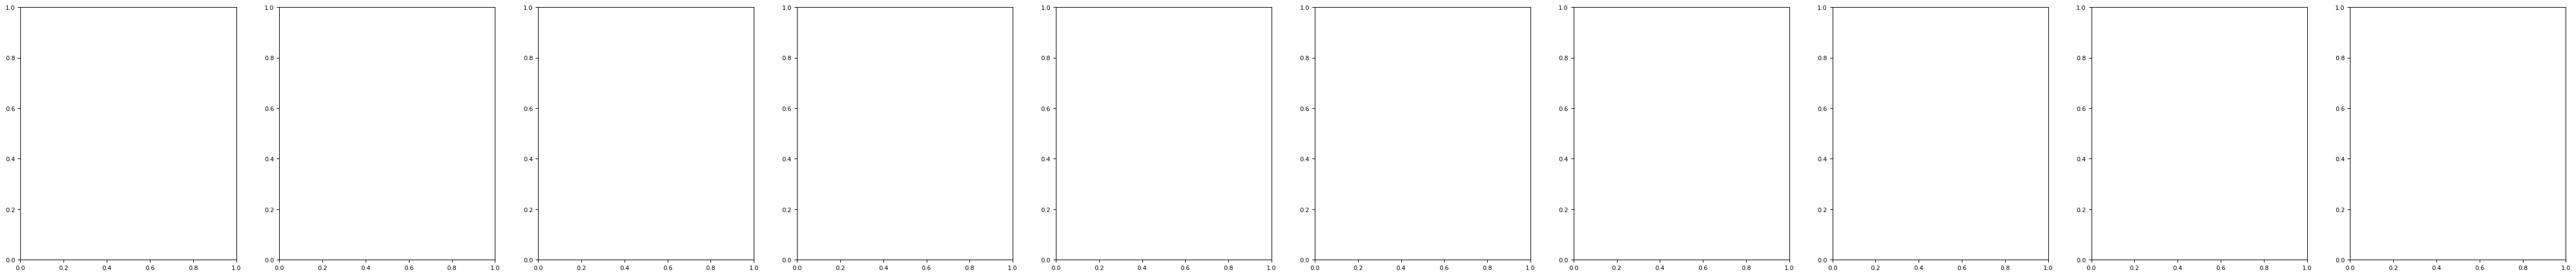

In [ ]:
# get population nmf components
n_components = 10

for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    f_nmf, axes_nmf = plt.subplots(1, n_components, figsize=(6 * n_components, 6))
    population_tuning_df = pdr.get_population_place_direction_tuning(
        subject_IDs="all",
        late_sessions=False,
        maze_name=maze_name,
    )
    simple_maze = mr.get_simple_maze(maze_name)
    pdr.plot_nmf_components(
        population_tuning_df,
        simple_maze,
        n_components=n_components,
        cmap="Reds",
        axes=axes_nmf,
    )

### Dimesionality reduction on behaviour

In [17]:
from GridMaze.analysis.core import get_sessions as gs
from GridMaze.analysis.behaviour import trajectory_plotting as tp

session = gs.get_maze_sessions(
    subject_IDs=["m3"], maze_names=["maze_1"], days_on_maze=[12], with_data=["trajectory_decisions_df"]
)

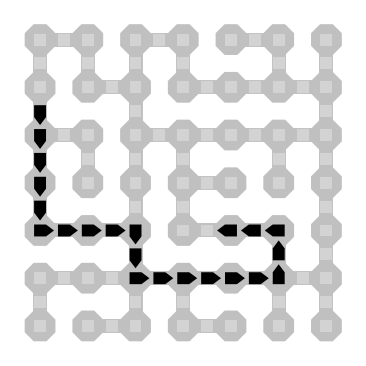

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(4.5, 4.5))
tp.plot_place_direction_trajectory(session, trial=46, ax=ax)

In [19]:
from GridMaze.analysis.behaviour import dimensionality_reduction as bdr

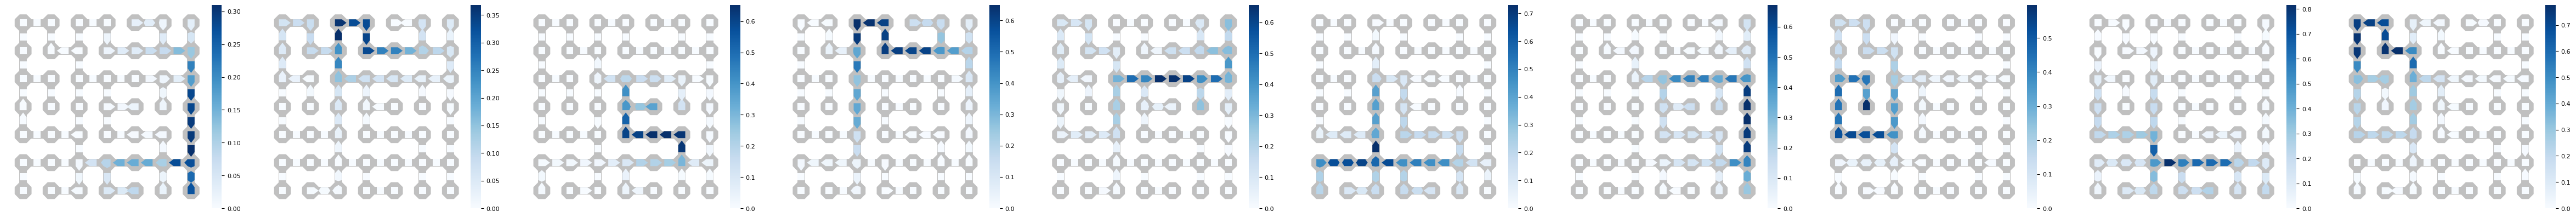

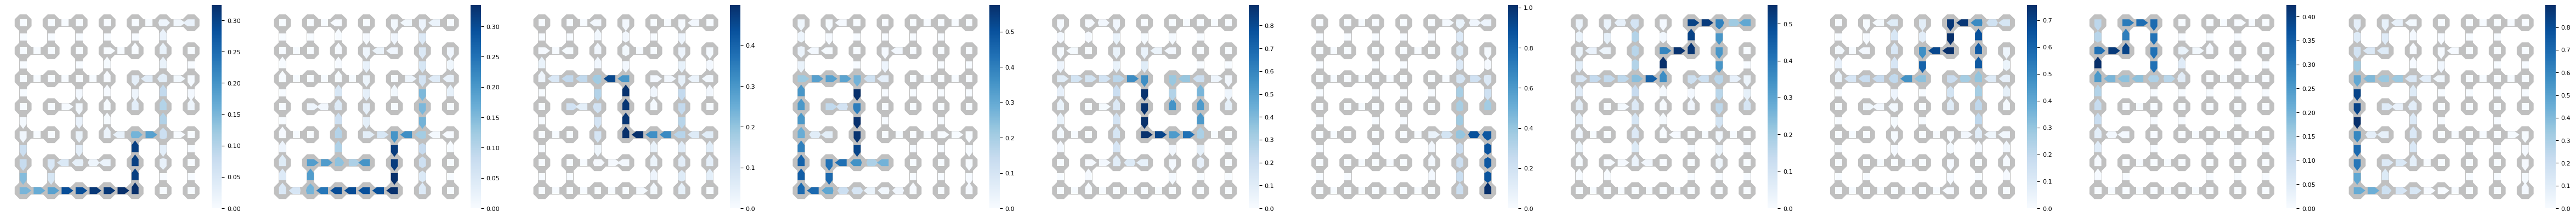

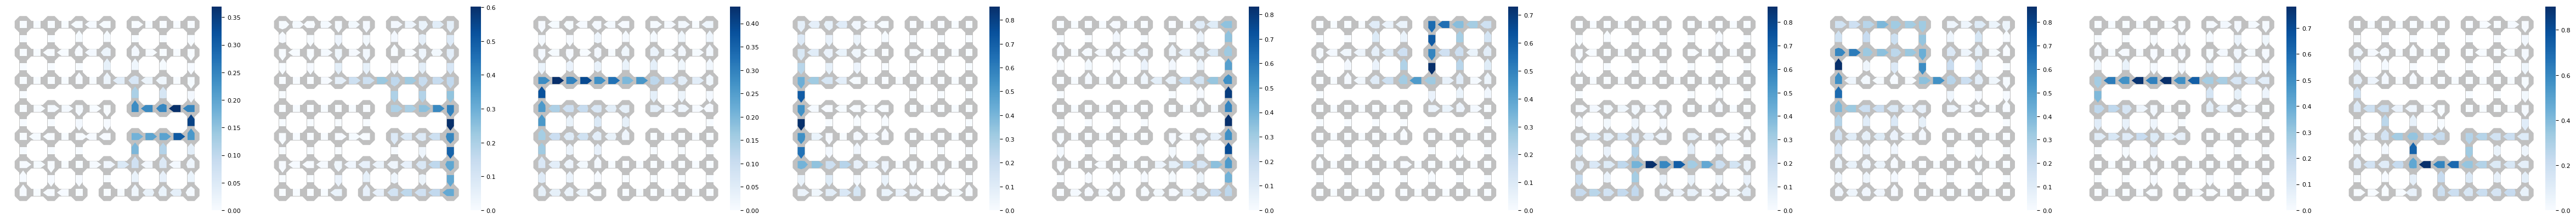

In [20]:
n_components = 10

for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    f_nmf, axes_nmf = plt.subplots(1, n_components, figsize=(6 * n_components, 6))

    population_tuning_df = bdr.get_maze_behavioural_sequences_df(
        subject_IDs="all",
        maze_name=maze_name,
        late_sessions=False,
        max_steps_to_goal=30,
    )
    simple_maze = mr.get_simple_maze(maze_name)
    bdr.plot_nmf_components(
        population_tuning_df,
        simple_maze,
        n_components=n_components,
        cmap="Blues",
        axes=axes_nmf,
    )

### efficient code for behavioural sequences

In [5]:
from GridMaze.analysis.place_direction import efficient_coding as ec

maze_1
comparison p-values:
                optimal  random_diffusion  true_behaviour
neural_data         0.0               0.0             0.0
true_behaviour      0.0               0.0             NaN
maze_2
comparison p-values:
                optimal  random_diffusion  true_behaviour
neural_data         0.0               0.0           0.002
true_behaviour      0.0               0.0             NaN
rooms_maze
comparison p-values:
                optimal  random_diffusion  true_behaviour
neural_data         0.0               0.0            0.01
true_behaviour      0.0               0.0             NaN


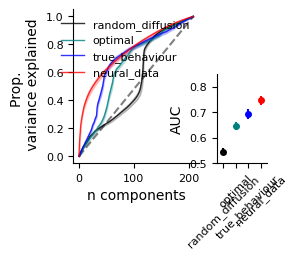

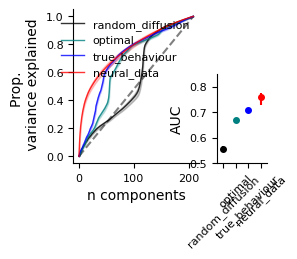

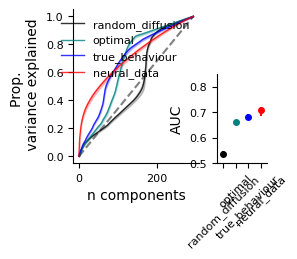

In [8]:
reload(ec)
for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    print(maze_name)
    auc_df, ve_df = ec.get_neural_variance_explained_by_synthetic_behaviour(maze_name)
    f = plt.figure(figsize=(2.5, 2))
    gs = f.add_gridspec(2, 2, width_ratios=(1, 0.4), height_ratios=(0.5, 1), hspace=0.3)
    axes = [f.add_subplot(gs[:, 0]), f.add_subplot(gs[1, 1])]
    ec.plot_neural_behavioural_ve_summary(
        auc_df, ve_df, axes=axes, colors=["red", "blue", "teal", "black"], print_stats=True
    )

In [ ]:
from GridMaze.analysis.place_direction import future_decoding as fd

summary_df = fd.get_place_decoding_summary()

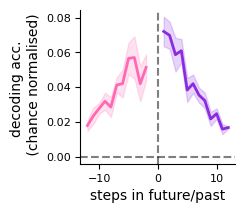

In [11]:
f, ax = plt.subplots(1, 1, figsize=(2, 2))
fd.plot_future_decoding_summary(summary_df, decision_points="future", plot_as="diff", ax=ax)

### Past/future decoding

# Supp figs

### Structure in place-direction tuning is not due to autocorrelation in beahviour and neurons

In [33]:
from GridMaze.analysis.place_direction import permuted_heatmaps as ph

maze_1
true vs permuted: 
     p_value: 0.000
maze_2
true vs permuted: 
     p_value: 0.000
rooms_maze
true vs permuted: 
     p_value: 0.000


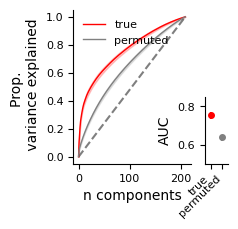

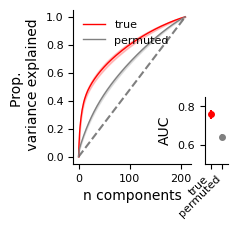

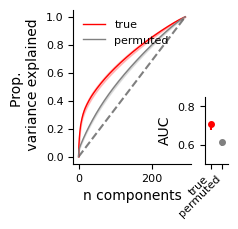

In [ ]:
reload(ph)
for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    print(maze_name)
    auc_df, ve_df = ph.get_true_vs_permuted_neural_variance_explained(maze_name)
    # plot
    f = plt.figure(figsize=(2, 2))
    gs = f.add_gridspec(2, 2, width_ratios=(1, 0.2), height_ratios=(1, 1), hspace=0.3)
    axes = [f.add_subplot(gs[:, 0]), f.add_subplot(gs[1, 1])]
    ph.plot_permuted_vs_true_summary(auc_df, ve_df, axes=axes, print_stats=True)

### Place-direction code is consistent across subjects

In [ ]:
from GridMaze.analysis.place_direction import efficient_coding as ec

reload(ec)

<module 'GridMaze.analysis.place_direction.efficient_coding' from '/ceph/behrens/peter_doohan/goalNav_mFC/experiment/code/GridMaze/analysis/place_direction/efficient_coding.py'>

maze_1
t=3.22, p=0.023
maze_2
t=4.31, p=0.008
rooms_maze
t=2.83, p=0.037


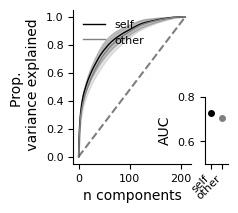

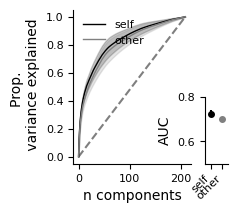

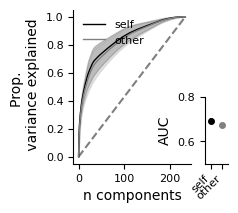

In [9]:
for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    print(maze_name)
    auc_df, ve_df = ec.get_place_direction_cross_subject_similarity(verbose=False)
    # plot
    f = plt.figure(figsize=(2, 2))
    gs = f.add_gridspec(2, 2, width_ratios=(1, 0.2), height_ratios=(1, 1), hspace=0.3)
    axes = [f.add_subplot(gs[:, 0]), f.add_subplot(gs[1, 1])]
    ec.plot_self_vs_other_cve_curves(auc_df, ve_df, maze_name=maze_name, axes=axes, print_stats=True)

### expanded neural/behavioural dimensionality reduction

In [ ]:
n_components = 10

for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    f_nmf, axes_nmf = plt.subplots(1, n_components, figsize=(6 * n_components, 6))
    f_pca, axes_pca = plt.subplots(1, n_components, figsize=(6 * n_components, 6))
    population_tuning_df = pdr.get_population_place_direction_tuning(
        subject_IDs="all",
        late_sessions=False,
        maze_name=maze_name,
    )
    simple_maze = mr.get_simple_maze(maze_name)
    pdr.plot_nmf_components(
        population_tuning_df,
        simple_maze,
        n_components=n_components,
        cmap="Reds",
        axes=axes_nmf,
    )
    pdr.plot_pca_components(
        population_tuning_df,
        simple_maze,
        n_components=n_components,
        cmap="coolwarm_r",
        axes=axes_pca,
    )

### behaviour is low dimensional

maze_1
maze_2
rooms_maze


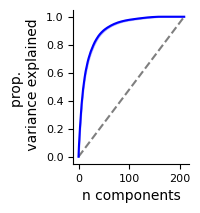

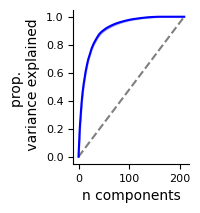

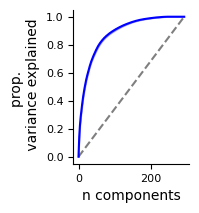

In [16]:
reload(ec)
for maze_name in ["maze_1", "maze_2", "rooms_maze"]:
    print(maze_name)
    df = ec.get_neural_behaviour_variance_explained(maze_name)
    f, ax = plt.subplots(1, 1, figsize=(1.5, 2), clear=True)
    ec.plot_cumulative_variance_explained(df, ax=ax)

In [ ]:
n_components = 10

for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    f_nmf, axes_nmf = plt.subplots(1, n_components, figsize=(6 * n_components, 6))
    f_pca, axes_pca = plt.subplots(1, n_components, figsize=(6 * n_components, 6))

    population_tuning_df = bdr.get_maze_behavioural_sequences_df(
        subject_IDs="all",
        maze_name=maze_name,
        late_sessions=False,
        max_steps_to_goal=30,
    )
    simple_maze = mr.get_simple_maze(maze_name)
    bdr.plot_nmf_components(
        population_tuning_df,
        simple_maze,
        n_components=n_components,
        cmap="Blues",
        axes=axes_nmf,
    )
    bdr.plot_pca_components(
        population_tuning_df,
        simple_maze,
        n_components=n_components,
        cmap="coolwarm_r",
        axes=axes_pca,
    )

In [ ]:
from GridMaze.analysis.unit_match import place_direction as umpd

In [ ]:
# unit matched dim red
n_components = 10
maze_pairs = [("maze_1", "maze_2"), ("maze_2", "rooms_maze")]
for maze_pair in maze_pairs:
    _maze_pair = f"{maze_pair[0]}.{maze_pair[1]}"
    f, axes = plt.subplots(2, n_components, figsize=(6 * n_components, 12))
    matched_heatmaps_df = umpd.get_matched_heatmaps_df(maze_pair)
    umpd.plot_cross_maze_nmf_components(matched_heatmaps_df, maze_pair, n_components=n_components, axes=axes)

In [ ]:
# neGLM summary
from GridMaze.analysis.neGLM import tuning_summaries as ts
from GridMaze.maze import representations as mr

In [ ]:
dim_red = "nmf"
n_components = 10
f, axes = plt.subplots(3, n_components, figsize=(6 * n_components, 18))
for i, maze_name in enumerate(["maze_1", "maze_2", "rooms_maze"]):
    simple_maze = mr.get_simple_maze(maze_name)
    place_direction_tuning_df = ts.get_population_unique_place_direction_tuning_df(maze_name=maze_name)
    ts.plot_unique_place_direction_components(
        place_direction_tuning_df, simple_maze, dim_red=dim_red, n_components=n_components, axes=axes[i, :]
    )

### remapping across mazes

In [ ]:
import numpy as np
from GridMaze.analysis.core import unit_matching as um
from GridMaze.analysis.unit_match import get_across_maze_matches as mm
from GridMaze.analysis.unit_match import place_direction as umpd

In [ ]:
# we can load neurons matched across mazes with UnitMatch like this:
matches = mm.get_cross_maze_matches(subject_ID="m3", maze_pair=("maze_2", "rooms_maze"), return_as="cluster_unique_ID")

In [ ]:
# but for convience I've pre-selected some cool cells for us to visualise
_select_clusters = [
    ("m3.2022-07-04.maze_cluster23", "m3.2022-07-11.maze_cluster131"),
    ("m3.2022-07-04.maze_cluster1", "m3.2022-07-08.maze_cluster27"),
    ("m3.2022-07-04.maze_cluster37", "m3.2022-07-07.maze_cluster61"),
    ("m2.2022-07-04.maze_cluster52", "m2.2022-07-07.maze_cluster52"),
    ("m3.2022-07-15.maze_cluster41", "m3.2022-07-20.maze_cluster43"),
    ("m3.2022-07-16.maze_cluster31", "m3.2022-07-24.maze_cluster56"),
]

# transform cluster_unique_IDs to Cluster objects (which makes plotting is easy)
select_clusters = np.array([[gc.get_cluster(C) for C in pair] for pair in _select_clusters])

In [ ]:
for i, pair in enumerate(select_clusters):
    f, axes = plt.subplots(1, 2, figsize=(12, 6))
    for Clust, ax in zip(pair, axes):
        Clust.plot_tuning(feature="place_direction", ax=ax)
        ax.set_title(f"{Clust.cluster_unique_ID}")
    f.suptitle(f"Match {i}")

In [ ]:
# are tuning patterns significantly correlated across mazes, let get some population summaries
maze_pairs = [
    ("maze_1", "maze_2"),
    (
        "maze_2",
        "rooms_maze",
    ),
]
for maze_pair in maze_pairs:
    _maze_pair = f"{maze_pair[0]}.{maze_pair[1]}"
    results = umpd.get_cross_maze_corr_summary(maze_pair=maze_pair)
    f, ax = plt.subplots(1, 1, figsize=(1.5, 3))
    umpd.plot_cross_maze_corrs_summary(results, print_stats=True, ax=ax)
    # save_path = f"../results/unit_match/place_direction/{_maze_pair}_corrs.pdf"
    f.savefig(save_path)

In [ ]:
n_components = 10
reload(umpd)
for maze_pair in maze_pairs:
    _maze_pair = f"{maze_pair[0]}.{maze_pair[1]}"
    f, axes = plt.subplots(2, n_components, figsize=(6 * n_components, 12))
    matched_heatmaps_df = umpd.get_matched_heatmaps_df(maze_pair)
    umpd.plot_cross_maze_nmf_components(matched_heatmaps_df, maze_pair, n_components=n_components, axes=axes)